# Analisis RMSE Estimasi SoC Baterai LiFePO4

Notebook ini disusun untuk menyelesaikan formulasi masalah skripsi:

> *Berapa tingkat persentase error (Root Mean Square Error/RMSE) dari estimasi State of Charge (SoC) baterai LiFePO4 menggunakan algoritma Extended Kalman Filter (EKF) dan metode Coulomb Counting (CC) jika dibandingkan dengan hasil SoC dari model baterai (OCV) pada pengujian pembebanan dinamis?*

**Dataset yang Digunakan:**
- `GroundTruth_OCV_SOC_LiFePO4.csv` (Sebagai acuan referensi visual kurva baterai)
- `Hasil_Simulasi_HiL_20260501_170643-done.csv` (Data hasil rekaman Injeksi Simulasi HiL ESP32)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

### 1. Plotting Karakteristik Kurva OCV (Ground Truth Model)
Mencetak grafik OCV terhadap SoC untuk memvalidasi karakteristik lengkungan (kurva) baterai LiFePO4 yang ideal berdasarkan ekstraksi *Cubic Spline*. Baterai LiFePO4 memiliki area dataran tegangan (*voltage plateau*) yang sangat ekstrem di kisaran 20% hingga 90%.

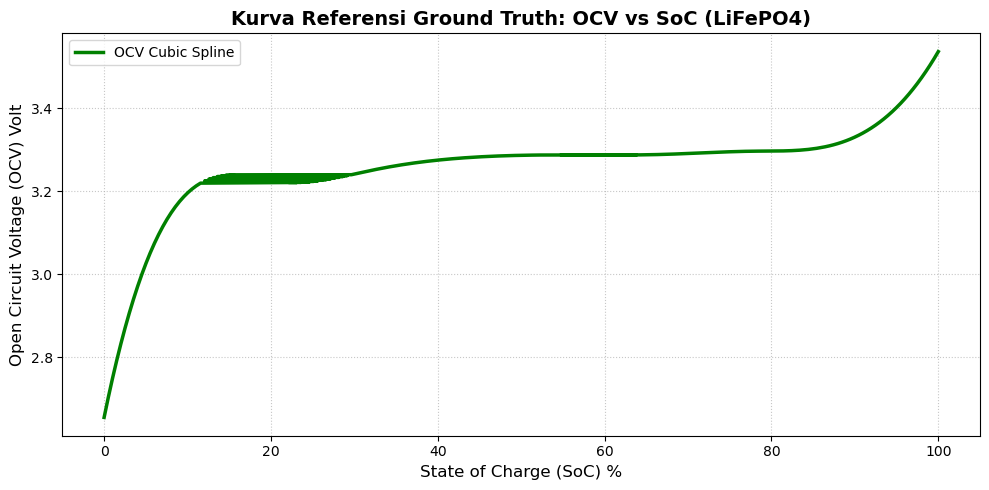

In [2]:
ocv_file = 'GroundTruth_OCV_SOC_LiFePO4.csv'
df_ocv = pd.read_csv(ocv_file)
df_ocv = df_ocv.drop_duplicates(subset=['OCV_Cubic_Spline (V)']).sort_values('OCV_Cubic_Spline (V)')

plt.figure(figsize=(10, 5))
plt.plot(df_ocv['SOC_Percentage (%)'], df_ocv['OCV_Cubic_Spline (V)'], 
         color='green', linewidth=2.5, label='OCV Cubic Spline')

plt.title('Kurva Referensi Ground Truth: OCV vs SoC (LiFePO4)', fontsize=14, fontweight='bold')
plt.xlabel('State of Charge (SoC) %', fontsize=12)
plt.ylabel('Open Circuit Voltage (OCV) Volt', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### 2. Memuat Hasil HiL & Menetapkan True SoC (Ground Truth)
Di dalam pengujian dinamis, kita tidak boleh memetakan Tegangan Terukur (`V_Meas`) secara langsung ke kurva OCV, karena `V_Meas` mengandung efek *voltage drop/rise* akibat resistansi internal ($I \times R$).

Oleh karena itu, **True SoC** diderivasi dari akumulasi profil arus aktual yang direkam oleh alat ukur presisi tinggi (ZKETECH). 

*(Catatan: Pengali x2 dilakukan karena laju rekam mesin asli adalah 2 detik, sementara ESP32 beroperasi di asumsi per 1 detik)*.

In [3]:
hil_file = 'Hasil_Simulasi_HiL_20260501_170643-done.csv'
df_hil = pd.read_csv(hil_file)

# ==========================================================================
# PENTING: TENTUKAN KONDISI FISIK BATERAI SAAT PENGUJIAN DIMULAI (0 - 100%)
# Skenario 1 (Charging dari kosong) -> Isi dengan 0.0
# Skenario 2/3 (Discharge dari penuh) -> Isi dengan 100.0
# ==========================================================================
ACTUAL_INITIAL_SOC = 0.0 

# Ekstraksi perubahan profil arus presisi ZKETECH 
delta_soc_cc = df_hil['SoC_CC(%)'].diff().fillna(0)

# Menyusun kolom referensi (Ground Truth) dan Metode CC ESP32
df_hil['SoC_GroundTruth(%)'] = np.clip(ACTUAL_INITIAL_SOC + (delta_soc_cc * 2).cumsum(), 0, 100)
df_hil['SoC_CC_Fixed(%)'] = df_hil['SoC_CC(%)'].iloc[0] + (delta_soc_cc * 2).cumsum()

print("Data Simulasi HiL & Ground Truth berhasil disusun! Total rekaman:", len(df_hil))

Data Simulasi HiL & Ground Truth berhasil disusun! Total rekaman: 10031


### 3. Perhitungan Tingkat Persentase Error (RMSE)
Bagian ini memecahkan formulasi masalah dengan membandingkan hasil estimasi SoC (EKF dan CC) terhadap `SoC_GroundTruth(%)`.

In [4]:
# Kalkulasi RMSE (Akurasi % Error)
rmse_cc = np.sqrt(mean_squared_error(df_hil['SoC_GroundTruth(%)'], df_hil['SoC_CC_Fixed(%)']))
rmse_ekf = np.sqrt(mean_squared_error(df_hil['SoC_GroundTruth(%)'], df_hil['SoC_EKF(%)']))

print("=========================================")
print(" HASIL KALKULASI ROOT MEAN SQUARE ERROR  ")
print("=========================================")
print(f"RMSE Metode Coulomb Counting : {rmse_cc:.4f} %")
print(f"RMSE Algoritma EKF           : {rmse_ekf:.4f} %")
print("=========================================")

 HASIL KALKULASI ROOT MEAN SQUARE ERROR  
RMSE Metode Coulomb Counting : 0.8182 %
RMSE Algoritma EKF           : 7.4321 %


### 4. Plotting & Visualisasi Grafik Perbandingan
Mencetak grafik garis (*Line Chart*) untuk membandingkan performa *tracking* SoC EKF terhadap metode tradisional CC.

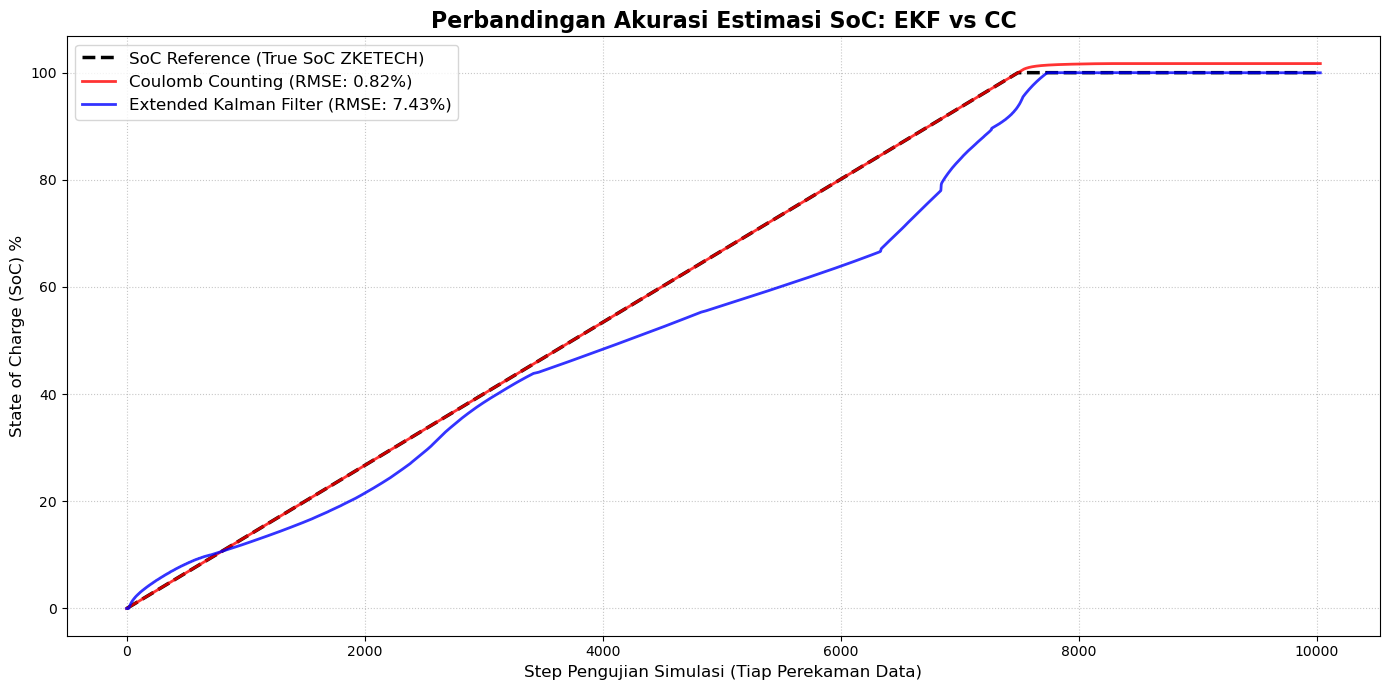

In [5]:
plt.figure(figsize=(14, 7))

# Garis Referensi (True SoC)
plt.plot(df_hil.index, df_hil['SoC_GroundTruth(%)'], label='SoC Reference (True SoC ZKETECH)', 
         linestyle='--', color='black', linewidth=2.5)

# Garis Hasil Metode Coulomb Counting
plt.plot(df_hil.index, df_hil['SoC_CC_Fixed(%)'], label=f'Coulomb Counting (RMSE: {rmse_cc:.2f}%)', 
         color='red', alpha=0.8, linewidth=2)

# Garis Hasil Algoritma EKF
plt.plot(df_hil.index, df_hil['SoC_EKF(%)'], label=f'Extended Kalman Filter (RMSE: {rmse_ekf:.2f}%)', 
         color='blue', alpha=0.8, linewidth=2)

plt.title('Perbandingan Akurasi Estimasi SoC: EKF vs CC', fontsize=16, fontweight='bold')
plt.xlabel('Step Pengujian Simulasi (Tiap Perekaman Data)', fontsize=12)
plt.ylabel('State of Charge (SoC) %', fontsize=12)
plt.legend(fontsize=12, loc='best')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
# Menyimpan hasil gambar grafik ke dalam folder aktif
plt.savefig('Grafik_Akurasi_SoC_RMSE.png', dpi=300)
plt.show()